# Phase 5 — Stacking Ensemble

**Goal:** Combine multiple base classifiers via Stacking using the best vectorizer from
Phase 4, then determine whether the ensemble beats the best single model.

**Stacking — how it works (the right way):**

1. Split training data into K folds
2. For each fold: train base models on the other K-1 folds, predict on the held-out fold
3. These out-of-fold predictions become the **meta-features** for a new training set
4. Train a **meta-learner** (Logistic Regression) on the meta-features
5. At test time: get predictions from all base models → feed as input to meta-learner

Using cross-validation (step 2) is critical — it prevents data leakage into the meta-features,
which would make the meta-learner see training labels it's trying to predict.
`StackingClassifier(cv=5)` implements this automatically.

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import time

from sklearn.ensemble          import StackingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.svm               import LinearSVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.naive_bayes       import ComplementNB
from sklearn.tree              import DecisionTreeClassifier
from sklearn.linear_model      import LogisticRegression

from evaluation import (evaluate_model, plot_confusion_matrix,
                         full_report, show_prediction_examples)

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')

print('Imports OK')

Imports OK


## 1. Load Best Vectorizer Decision & Features

In [2]:
with open(os.path.join(RES_DIR, 'best_vectorizer.json'), encoding='utf-8') as f:
    decision = json.load(f)

best_vec        = decision['best_vectorizer']
best_model_name = decision['best_model']
best_single_f1  = decision['best_model_f1']
best_single_acc = decision['best_model_accuracy']

print(f'Best vectorizer from Phase 4: {best_vec}')
print(f'Best single model           : {best_model_name}  (F1={best_single_f1:.4f})')

Best vectorizer from Phase 4: CountVectorizer
Best single model           : RandomForest  (F1=0.8384)


In [3]:
# Load the appropriate feature matrices
vec_file_map = {
    'CountVectorizer': ('X_train_count.npz', 'X_test_count.npz', 'sparse'),
    'TF-IDF':          ('X_train_tfidf.npz', 'X_test_tfidf.npz', 'sparse'),
    'Word2Vec':        ('X_train_w2v.npy',   'X_test_w2v.npy',   'dense'),
}

tr_file, te_file, kind = vec_file_map[best_vec]

if kind == 'sparse':
    X_train = sp.load_npz(os.path.join(DATA_PROC, tr_file))
    X_test  = sp.load_npz(os.path.join(DATA_PROC, te_file))
else:
    X_train = np.load(os.path.join(DATA_PROC, tr_file))
    X_test  = np.load(os.path.join(DATA_PROC, te_file))

y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

test_df = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'), encoding='utf-8')
X_test_texts = test_df['cleaned'].fillna('').values

print(f'Feature matrix: {X_train.shape}  (type={kind})')

Feature matrix: (55577, 50000)  (type=sparse)


## 2. Stacking Architecture

**Base learners selected:**

| Model | Reason for inclusion |
|---|---|
| `ComplementNB` | Fast, strong baseline for sparse text; different error profile from SVM |
| `SVM (Linear, calibrated)` | Usually best single model; provides strong anchor predictions |
| `RandomForest` | Non-linear; can catch patterns that linear models miss |
| `DecisionTree` | Interpretable; makes mistakes different from RF and SVM |
| `AdaBoost` | Focuses on hard examples; complementary to RF |

**Diversity is key** — base models should make different mistakes so the meta-learner
can learn to correct them.  SVM is strong on clear-cut cases; tree models may handle
borderline cases differently; NB can be surprisingly accurate on keyword-dominated reviews.

**Meta-learner:** `LogisticRegression` — regularized, low variance, standard choice.

In [4]:
base_estimators = [
    ('nb',   ComplementNB(alpha=0.1)),
    ('svm',  CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000))),
    ('rf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)),
    ('dt',   DecisionTreeClassifier(max_depth=20, random_state=42)),
    ('ada',  AdaBoostClassifier(n_estimators=100, random_state=42)),
]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,              # 5-fold CV for out-of-fold meta-features (no leakage)
    stack_method='auto',  # uses predict_proba when available
    n_jobs=-1,
    passthrough=False, # only feed base model outputs to meta-learner
)

print('StackingClassifier configured.')
print(f'Base models: {[name for name, _ in base_estimators]}')
print(f'Meta-learner: {type(meta_learner).__name__}')
print(f'CV folds: 5')

StackingClassifier configured.
Base models: ['nb', 'svm', 'rf', 'dt', 'ada']
Meta-learner: LogisticRegression
CV folds: 5


## 3. Train the Stacking Model

Training will take several minutes — StackingClassifier trains each base model
K+1 times (K folds for meta-features + 1 final fit on full training data).

In [5]:
print(f'Training StackingClassifier on {best_vec} features...')
print('(5 base models × 5 CV folds + 1 final fit each = ~30 fits total)')

t0 = time.time()
stacking_clf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'Done. Training time: {elapsed:.1f}s ({elapsed/60:.1f} min)')

Training StackingClassifier on CountVectorizer features...
(5 base models × 5 CV folds + 1 final fit each = ~30 fits total)


Done. Training time: 603.9s (10.1 min)


## 4. Evaluate

In [6]:
y_pred_stack = stacking_clf.predict(X_test)

stack_metrics = evaluate_model('Stacking', best_vec, y_test, y_pred_stack)
print('Stacking Ensemble Metrics:')
for k, v in stack_metrics.items():
    print(f'  {k:<15}: {v}')

full_report('StackingClassifier', best_vec, y_test, y_pred_stack)

Stacking Ensemble Metrics:
  model          : Stacking
  vectorizer     : CountVectorizer
  accuracy       : 0.8455
  precision      : 0.8474
  recall         : 0.8455
  f1             : 0.8453

Model: StackingClassifier   |   Vectorizer: CountVectorizer
              precision    recall  f1-score   support

         Sad       0.82      0.88      0.85      6912
       Happy       0.87      0.81      0.84      6983

    accuracy                           0.85     13895
   macro avg       0.85      0.85      0.85     13895
weighted avg       0.85      0.85      0.85     13895



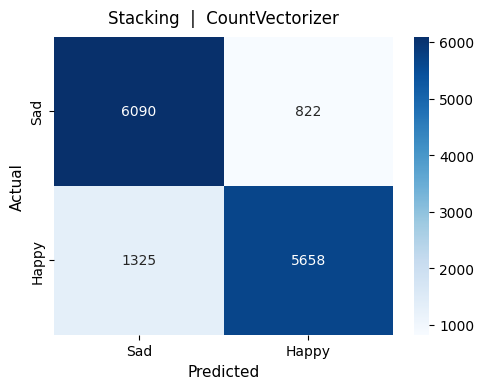

In [7]:
plot_confusion_matrix('Stacking', best_vec, y_test, y_pred_stack, CM_DIR, show=True)

## 5. Stacking vs. Best Single Model

In [8]:
comparison = pd.DataFrame([
    {
        'Model':      best_model_name + ' (best single)',
        'Vectorizer': best_vec,
        'Accuracy':   best_single_acc,
        'F1':         best_single_f1,
    },
    {
        'Model':      'StackingClassifier',
        'Vectorizer': best_vec,
        'Accuracy':   stack_metrics['accuracy'],
        'F1':         stack_metrics['f1'],
    },
])

comparison['Δ F1'] = comparison['F1'].diff().fillna(0)
print(comparison.to_string(index=False))

f1_diff = stack_metrics['f1'] - best_single_f1
if f1_diff > 0:
    print(f'\nStacking IMPROVES F1 by {f1_diff:+.4f} over the best single model.')
else:
    print(f'\nStacking does NOT improve over the best single model (Δ F1 = {f1_diff:+.4f}).')
    print('This is a valid scientific result — the base models may be too similar,')
    print('or the best single model already captures most learnable signal.')

                     Model      Vectorizer  Accuracy     F1   Δ F1
RandomForest (best single) CountVectorizer    0.8386 0.8384 0.0000
        StackingClassifier CountVectorizer    0.8455 0.8453 0.0069

Stacking IMPROVES F1 by +0.0069 over the best single model.


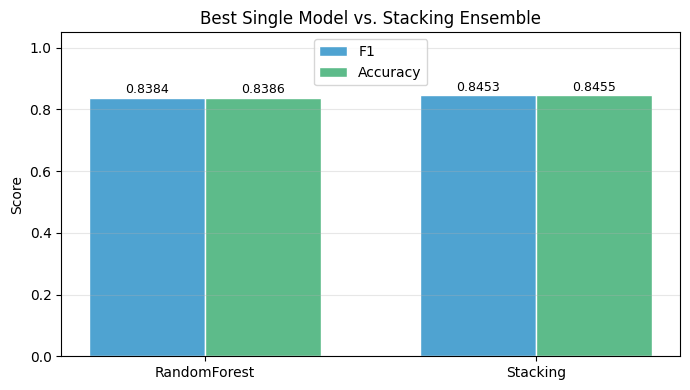

In [9]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
labels = [best_model_name, 'Stacking']
f1_vals  = [best_single_f1,    stack_metrics['f1']]
acc_vals = [best_single_acc,   stack_metrics['accuracy']]

x     = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, f1_vals,  width, label='F1',       color='#4FA3D1', edgecolor='white')
ax.bar(x + width/2, acc_vals, width, label='Accuracy',  color='#5DBB8A', edgecolor='white')

for rect, val in zip(ax.patches, f1_vals + acc_vals):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Best Single Model vs. Stacking Ensemble', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stacking_vs_best.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Prediction Examples

In [10]:
show_prediction_examples(
    texts=X_test_texts,
    y_true=y_test,
    y_pred=y_pred_stack,
    n=5,
    label_map={0: 'Sad', 1: 'Happy'}
)

CORRECT PREDICTIONS (showing 5)
  Text  : کیک یخ‌زده محتویات لای کیک جمله گردو موز سفت
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : شیرینی نارگیل قسمت کیکیش بیات توی جعبه شیرینی ناپلئون بد رولت واقعا کهنه لطیفه خامه معمولی
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : شیرینی رولت صورت لهشذه خورد دستم
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : قیمت اسپری مو درج‌شده تصویر ارسال
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : عکس اصلا تازه مدل شیرینی سفارش داد
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------

INCORRECT PREDICTIONS (showing 5)
  Text  : قطعات جوجه درشت طبخ نامناسبی
  True  : Happy   |   Predicted: Sad
---------------------------------------

## 7. Save Final Results

In [11]:
import json
final = {
    'stacking_accuracy':  stack_metrics['accuracy'],
    'stacking_precision': stack_metrics['precision'],
    'stacking_recall':    stack_metrics['recall'],
    'stacking_f1':        stack_metrics['f1'],
    'best_single_model':  best_model_name,
    'best_single_f1':     best_single_f1,
    'delta_f1':           round(stack_metrics['f1'] - best_single_f1, 4),
    'vectorizer_used':    best_vec,
}
with open(os.path.join(RES_DIR, 'phase5_stacking_results.json'), 'w', encoding='utf-8') as f:
    json.dump(final, f, indent=2)

print('Saved: outputs/results/phase5_stacking_results.json')
print(json.dumps(final, indent=2))

Saved: outputs/results/phase5_stacking_results.json
{
  "stacking_accuracy": 0.8455,
  "stacking_precision": 0.8474,
  "stacking_recall": 0.8455,
  "stacking_f1": 0.8453,
  "best_single_model": "RandomForest",
  "best_single_f1": 0.8384,
  "delta_f1": 0.0069,
  "vectorizer_used": "CountVectorizer"
}


## 8. Summary

| Item | Value |
|---|---|
| Vectorizer used | Best from Phase 4 |
| Base models | ComplementNB, SVM, RandomForest, DecisionTree, AdaBoost |
| Meta-learner | LogisticRegression |
| CV folds | 5 |
| Stacking F1 | see output |
| Best single F1 | see output |
| Improvement | see Δ F1 |

**Pipeline complete.** All notebooks from Phase 1–5 are done.
Results are in `outputs/results/`. Figures are in `outputs/figures/`.
Report can now be written in `report/*.tex`.